# 🛒 Customer Intelligence System
## Phase 2: Preprocessing & Feature Engineering

**Dataset:** E-commerce User Behavioral Dataset  
**Goal:** Encode categoricals, scale numerics, engineer domain features, and export a clean feature matrix for segmentation & ML.

---
### Notebook Sections
1. Setup & Data Loading
2. Categorical Encoding
3. Numeric Scaling
4. Feature Engineering
   - `engagement_score`
   - `value_score`
   - `risk_score`
5. Final Feature Matrix
6. Save Preprocessed Data

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')

# Plot styling (consistent with Phase 1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
COLORS = sns.color_palette('muted', 10)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
# Load raw dataset (same file as EDA)
FILE_PATH = 'e_commerce_shopper_behaviour_and_lifestyle.csv'  # ← Update path if needed

df_raw = pd.read_csv(FILE_PATH)
df = df_raw.copy()  # We always work on a copy — never mutate raw data

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {df.shape[1]}')
print('\n🔍 First 3 rows:')
df.head(3)

Dataset shape : (1000000, 60)
Columns       : 60

🔍 First 3 rows:


,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,10,2,62,7,74,19,2025-06-22,6,1,50
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,5,7,54,5,23,8,2026-07-25,3,0,37
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,3,3,33,7,12,13,2026-02-26,6,0,53


In [3]:
# Quick column audit
dtypes = df.dtypes.reset_index()
dtypes.columns = ['Column', 'dtype']
dtypes['Category'] = dtypes['dtype'].apply(
    lambda x: 'Numeric' if x in [np.float64, np.int64, 'float64', 'int64'] else 'Categorical'
)

print('=== COLUMN AUDIT ===')
print(f'Total columns      : {len(df.columns)}')
print(f'Numeric columns    : {(dtypes["Category"]=="Numeric").sum()}')
print(f'Categorical columns: {(dtypes["Category"]=="Categorical").sum()}')
print('\nCategorical columns:')
print(dtypes[dtypes['Category']=='Categorical']['Column'].tolist())

=== COLUMN AUDIT ===
Total columns      : 60
Numeric columns    : 45
Categorical columns: 15

Categorical columns:
['gender', 'country', 'urban_rural', 'employment_status', 'education_level', 'relationship_status', 'occupation', 'ethnicity', 'language_preference', 'device_type', 'preferred_payment_method', 'product_category_preference', 'shopping_time_of_day', 'budgeting_style', 'last_purchase_date']


## 2. Categorical Encoding

We use different encoding strategies depending on cardinality and feature type:
- **Binary categoricals** (Yes/No, M/F) → Label Encoding (0/1)
- **Low-cardinality nominals** (gender, occupation, country) → One-Hot Encoding
- **Ordinals** (education level, income bracket if present) → Ordinal Encoding with meaningful order

In [4]:
# Identify categorical columns and their unique value counts
cat_cols = df.select_dtypes(include='object').columns.tolist()

cat_profile = pd.DataFrame({
    'Column': cat_cols,
    'Unique Values': [df[c].nunique() for c in cat_cols],
    'Sample Values': [df[c].unique()[:5].tolist() for c in cat_cols]
}).sort_values('Unique Values')

print('=== CATEGORICAL COLUMN PROFILE ===')
display(cat_profile.set_index('Column'))

=== CATEGORICAL COLUMN PROFILE ===


,Unique Values,Sample Values
Column,,
urban_rural,3,"[Suburban, Urban, Rural]"
device_type,3,"[Mobile, Desktop, Tablet]"
budgeting_style,3,"[Strict, Loose, Moderate]"
gender,4,"[Female, Male, Non-binary, Other]"
shopping_time_of_day,4,"[Morning, Afternoon, Evening, Night]"
employment_status,5,"[Self-employed, Unemployed, Employed, Student,..."
education_level,5,"[Associate Degree, Bachelor, High School, Mast..."
relationship_status,5,"[Single, Married, Widowed, In a relationship, ..."
ethnicity,5,"[Other, Hispanic, Asian, Caucasian, African Am..."


In [5]:
# ── Step 2A: Binary string columns → 0/1 ────────────────────────────────────
# These are already stored as 0/1 integers in the dataset (has_children,
# loyalty_program_member, etc.). Only needed if they came in as Yes/No strings.

yes_no_cols = [c for c in cat_cols if set(df[c].dropna().str.lower().unique()).issubset({'yes', 'no'})]

for col in yes_no_cols:
    df[col] = df[col].str.lower().map({'yes': 1, 'no': 0})
    print(f'  Encoded (Yes/No → 0/1): {col}')

if not yes_no_cols:
    print('ℹ️  No Yes/No string columns found — binary columns are already numeric.')

ℹ️  No Yes/No string columns found — binary columns are already numeric.


In [6]:
# ── Step 2B: Gender encoding ─────────────────────────────────────────────────
# Check if gender column exists and encode it

if 'gender' in df.columns and df['gender'].dtype == object:
    print('Gender unique values:', df['gender'].unique())
    gender_map = {v: i for i, v in enumerate(sorted(df['gender'].dropna().unique()))}
    df['gender_encoded'] = df['gender'].map(gender_map)
    print(f'Gender mapping: {gender_map}')
    df = df.drop(columns=['gender'])
    print('✅ Gender encoded')
else:
    print('ℹ️  Gender column is already numeric or not found.')

Gender unique values: ['Female' 'Male' 'Non-binary' 'Other']
Gender mapping: {'Female': 0, 'Male': 1, 'Non-binary': 2, 'Other': 3}
✅ Gender encoded


In [7]:
# ── Step 2C: One-Hot Encoding for nominal categoricals ───────────────────────
# Refresh the list of remaining object columns
cat_cols_remaining = df.select_dtypes(include='object').columns.tolist()

# Columns to exclude from OHE (e.g. IDs, free-text)
EXCLUDE_FROM_OHE = ['user_id']  # add any free-text/ID columns here

ohe_cols = [c for c in cat_cols_remaining if c not in EXCLUDE_FROM_OHE]

if ohe_cols:
    print(f'One-Hot Encoding columns: {ohe_cols}')
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)
    print(f'Shape after OHE: {df.shape}')
    new_ohe_cols = [c for c in df.columns if any(c.startswith(base + '_') for base in ohe_cols)]
    print(f'New OHE columns created: {len(new_ohe_cols)}')
else:
    print('ℹ️  No nominal categorical columns remain for OHE.')

One-Hot Encoding columns: ['country', 'urban_rural', 'employment_status', 'education_level', 'relationship_status', 'occupation', 'ethnicity', 'language_preference', 'device_type', 'preferred_payment_method', 'product_category_preference', 'shopping_time_of_day', 'budgeting_style', 'last_purchase_date']
Shape after OHE: (1000000, 848)
New OHE columns created: 802


In [8]:
# Confirm no object columns remain (except user_id)
remaining_obj = df.select_dtypes(include='object').columns.tolist()
remaining_obj_filtered = [c for c in remaining_obj if c != 'user_id']

if remaining_obj_filtered:
    print(f'⚠️  Still have object columns: {remaining_obj_filtered}')
    print('Inspect these and encode manually if needed.')
else:
    print('✅ All categorical columns encoded — no object dtype columns remaining (excluding user_id).')

print(f'\nCurrent shape: {df.shape}')

✅ All categorical columns encoded — no object dtype columns remaining (excluding user_id).

Current shape: (1000000, 848)


## 3. Numeric Scaling

We use **StandardScaler** for ML models (zero mean, unit variance) and keep a **MinMax-scaled** copy for clustering (KMeans is distance-based).

| Use-case | Scaler | Why |
|---|---|---|
| KMeans Clustering | MinMaxScaler | Bounded [0,1], no outlier distortion on distances |
| Random Forest / XGBoost | No scaling needed | Tree-based — invariant to monotonic transforms |
| Logistic Regression / Ridge | StandardScaler | Assumes normally distributed features |
| PCA | StandardScaler | Variance-sensitive — must standardize first |

In [9]:
# Identify numeric columns to scale (exclude IDs and already-binary cols)
NON_SCALE_COLS = ['user_id']  # IDs, binary flags are fine to exclude

# Treat OHE binary dummies as already [0,1] — no need to scale those
ohe_dummy_cols = [c for c in df.columns 
                  if any(c.startswith(base + '_') for base in ohe_cols)] if ohe_cols else []

# Core binary flag columns (already 0/1)
binary_flag_cols = ['has_children', 'loyalty_program_member', 'weekend_shopper',
                    'premium_subscription', 'gender_encoded']
binary_flag_cols = [c for c in binary_flag_cols if c in df.columns]

# Numeric cols eligible for scaling
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
scale_cols = [c for c in numeric_cols 
              if c not in NON_SCALE_COLS + ohe_dummy_cols + binary_flag_cols]

print(f'Columns to scale       : {len(scale_cols)}')
print(f'OHE dummy cols (skip)  : {len(ohe_dummy_cols)}')
print(f'Binary flag cols (skip): {len(binary_flag_cols)}')
print(f'\nScale columns:\n{scale_cols}')

Columns to scale       : 40
OHE dummy cols (skip)  : 802
Binary flag cols (skip): 5

Scale columns:
['age', 'income_level', 'household_size', 'weekly_purchases', 'monthly_spend', 'cart_abandonment_rate', 'review_writing_frequency', 'average_order_value', 'coupon_usage_frequency', 'referral_count', 'impulse_purchases_per_month', 'browse_to_buy_ratio', 'return_frequency', 'brand_loyalty_score', 'impulse_buying_score', 'environmental_consciousness', 'health_conscious_shopping', 'travel_frequency', 'hobby_count', 'social_media_influence_score', 'reading_habits', 'exercise_frequency', 'stress_from_financial_decisions', 'overall_stress_level', 'sleep_quality', 'physical_activity_level', 'mental_health_score', 'daily_session_time_minutes', 'product_views_per_day', 'ad_views_per_day', 'ad_clicks_per_day', 'wishlist_items_count', 'cart_items_average', 'checkout_abandonments_per_month', 'purchase_conversion_rate', 'app_usage_frequency', 'notification_response_rate', 'account_age_months', 'social

In [10]:
# ── StandardScaler (for logistic regression, ridge, PCA) ─────────────────────
std_scaler = StandardScaler()
df_std = df.copy()
df_std[scale_cols] = std_scaler.fit_transform(df[scale_cols])

print('✅ StandardScaler applied')
print(f'Mean of scaled cols (should ≈ 0): {df_std[scale_cols].mean().mean():.6f}')
print(f'Std  of scaled cols (should ≈ 1): {df_std[scale_cols].std().mean():.4f}')

✅ StandardScaler applied
Mean of scaled cols (should ≈ 0): -0.000000
Std  of scaled cols (should ≈ 1): 1.0000


In [11]:
# ── MinMaxScaler (for KMeans clustering) ─────────────────────────────────────
mm_scaler = MinMaxScaler()
df_mm = df.copy()
df_mm[scale_cols] = mm_scaler.fit_transform(df[scale_cols])

print('✅ MinMaxScaler applied')
print(f'Min of scaled cols (should = 0): {df_mm[scale_cols].min().min():.4f}')
print(f'Max of scaled cols (should = 1): {df_mm[scale_cols].max().max():.4f}')

✅ MinMaxScaler applied
Min of scaled cols (should = 0): 0.0000
Max of scaled cols (should = 1): 1.0000


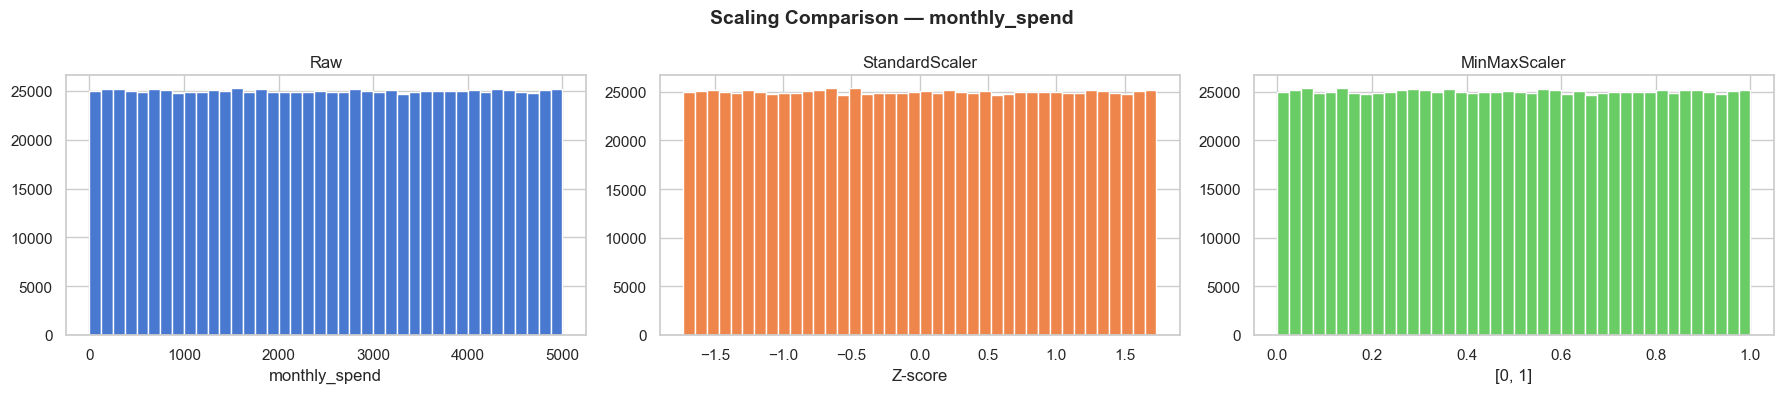

In [12]:
# Visual check: before vs after scaling for a key feature
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Scaling Comparison — monthly_spend', fontsize=14, fontweight='bold')

check_col = 'monthly_spend'

axes[0].hist(df[check_col], bins=40, color=COLORS[0], edgecolor='white')
axes[0].set_title('Raw')
axes[0].set_xlabel(check_col)

axes[1].hist(df_std[check_col], bins=40, color=COLORS[1], edgecolor='white')
axes[1].set_title('StandardScaler')
axes[1].set_xlabel('Z-score')

axes[2].hist(df_mm[check_col], bins=40, color=COLORS[2], edgecolor='white')
axes[2].set_title('MinMaxScaler')
axes[2].set_xlabel('[0, 1]')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

We derive three composite domain scores, each capturing a distinct behavioral dimension:

| Feature | Formula | What it captures |
|---|---|---|
| `engagement_score` | ad_clicks + notification_response + app_usage | Digital channel responsiveness |
| `value_score` | monthly_spend × loyalty × referral_count | Revenue value & advocacy |
| `risk_score` | return_rate + cart_abandonment + checkout_abandonments | Friction & churn signals |

In [13]:
# We engineer on the RAW (unscaled) df first, then scale the new features.

# ── 4.1 engagement_score ─────────────────────────────────────────────────────
# Captures how actively a user engages with digital marketing channels.
# Components: ad_clicks_per_day, notification_response_rate, app_usage_frequency

# Normalize each component to [0,1] before summing so no single feature dominates
def minmax_norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

eng_components = ['ad_clicks_per_day', 'notification_response_rate', 'app_usage_frequency']

# Check components exist
missing_eng = [c for c in eng_components if c not in df.columns]
if missing_eng:
    print(f'⚠️  Missing engagement components: {missing_eng}')
    print('Using available components only.')
    eng_components = [c for c in eng_components if c in df.columns]

df['engagement_score'] = sum(minmax_norm(df[c]) for c in eng_components)

print(f'✅ engagement_score created using: {eng_components}')
print(f'   Range: {df["engagement_score"].min():.3f} – {df["engagement_score"].max():.3f}')
print(f'   Mean : {df["engagement_score"].mean():.3f}')

✅ engagement_score created using: ['ad_clicks_per_day', 'notification_response_rate', 'app_usage_frequency']
   Range: 0.000 – 3.000
   Mean : 1.499


In [14]:
# ── 4.2 value_score ───────────────────────────────────────────────────────────
# High-value customers: high spend, loyal, and refer others.
# Formula: monthly_spend × loyalty_program_member × (1 + referral_count)
# Note: We use (1 + referral_count) to avoid zeroing out non-referrers.

val_components = {
    'spend': 'monthly_spend',
    'loyalty': 'loyalty_program_member',
    'referral': 'referral_count'
}

missing_val = [v for v in val_components.values() if v not in df.columns]
if missing_val:
    print(f'⚠️  Missing value_score components: {missing_val}')

spend_norm    = minmax_norm(df[val_components['spend']])
loyalty_boost = (1 + df[val_components['loyalty']])  # 1 for non-member, 2 for member
referral_norm = minmax_norm(1 + df[val_components['referral']])

df['value_score'] = spend_norm * loyalty_boost * referral_norm

print(f'✅ value_score created')
print(f'   Range: {df["value_score"].min():.4f} – {df["value_score"].max():.4f}')
print(f'   Mean : {df["value_score"].mean():.4f}')

✅ value_score created
   Range: 0.0000 – 2.0000
   Mean : 0.3751


In [15]:
# ── 4.3 risk_score ────────────────────────────────────────────────────────────
# High-risk customers are likely to churn, return goods, or drop from the funnel.
# Components: return_rate, cart_abandonment_rate, checkout_abandonments_per_month

risk_components = ['return_rate', 'cart_abandonment_rate', 'checkout_abandonments_per_month']

missing_risk = [c for c in risk_components if c not in df.columns]
if missing_risk:
    print(f'⚠️  Missing risk components: {missing_risk}')
    risk_components = [c for c in risk_components if c in df.columns]

df['risk_score'] = sum(minmax_norm(df[c]) for c in risk_components)

print(f'✅ risk_score created using: {risk_components}')
print(f'   Range: {df["risk_score"].min():.3f} – {df["risk_score"].max():.3f}')
print(f'   Mean : {df["risk_score"].mean():.3f}')

✅ risk_score created using: ['return_rate', 'cart_abandonment_rate', 'checkout_abandonments_per_month']
   Range: 0.000 – 3.000
   Mean : 1.447


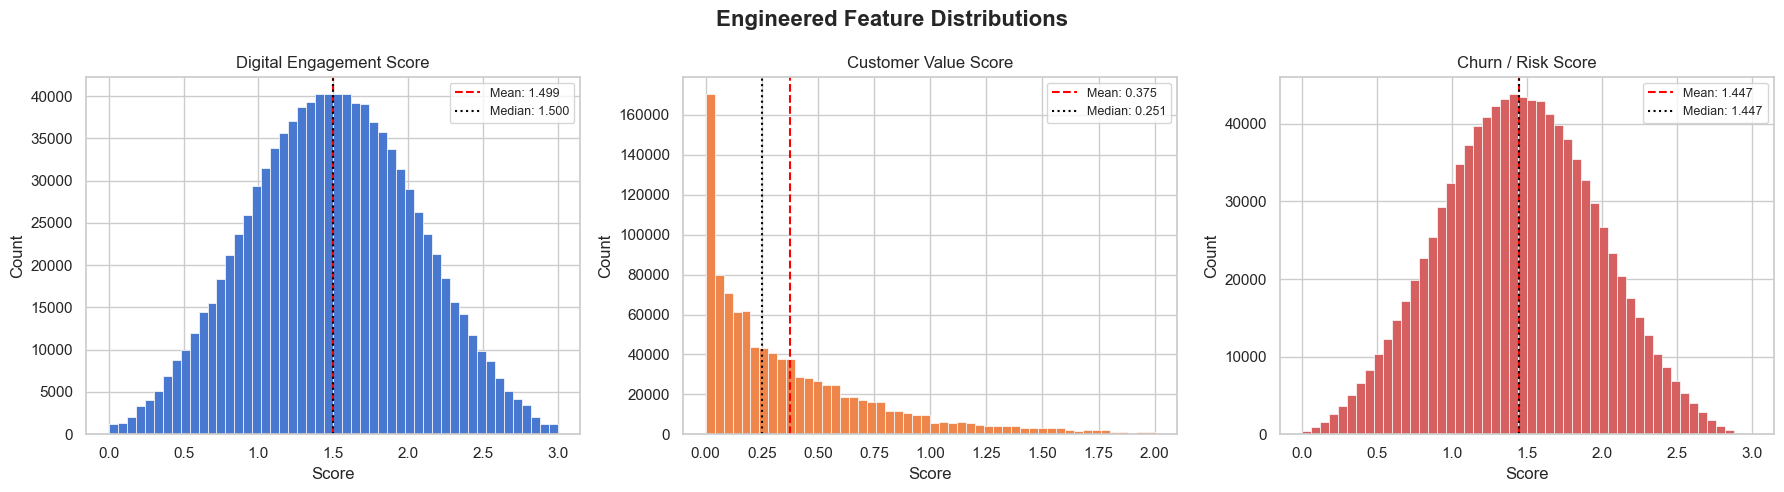

In [16]:
# ── Distribution plots for all three engineered features ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Engineered Feature Distributions', fontsize=16, fontweight='bold')

feat_info = [
    ('engagement_score', COLORS[0], 'Digital Engagement Score'),
    ('value_score',      COLORS[1], 'Customer Value Score'),
    ('risk_score',       COLORS[3], 'Churn / Risk Score'),
]

for ax, (col, color, title) in zip(axes, feat_info):
    ax.hist(df[col], bins=50, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.3f}')
    ax.axvline(df[col].median(), color='black',  linestyle=':',  linewidth=1.5,
               label=f'Median: {df[col].median():.3f}')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

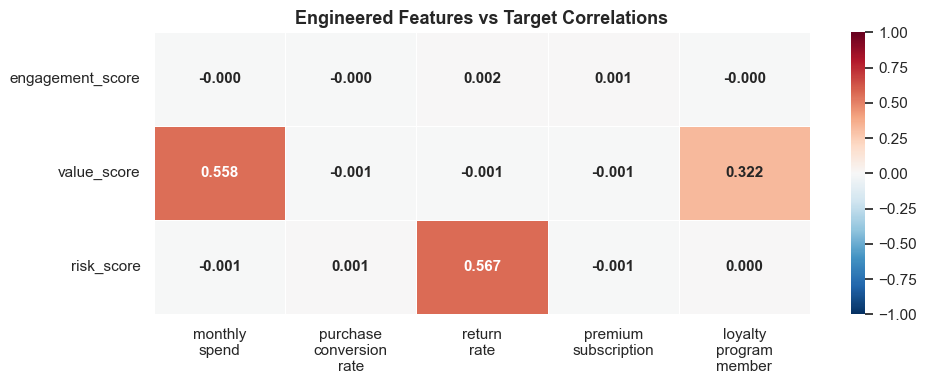


📊 Correlation table:


,monthly_spend,purchase_conversion_rate,return_rate,premium_subscription,loyalty_program_member
engagement_score,-0.000,-0.000,0.002,0.001,-0.000
value_score,0.558,-0.001,-0.001,-0.001,0.322
risk_score,-0.001,0.001,0.567,-0.001,0.000


In [17]:
# ── Correlation of engineered features vs key targets ─────────────────────────
target_cols = ['monthly_spend', 'purchase_conversion_rate', 'return_rate',
               'premium_subscription', 'loyalty_program_member']
target_cols = [c for c in target_cols if c in df.columns]

engineered = ['engagement_score', 'value_score', 'risk_score']
corr_check = df[engineered + target_cols].corr().loc[engineered, target_cols]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(corr_check, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Engineered Features vs Target Correlations', fontsize=13, fontweight='bold')
ax.set_xticklabels([c.replace('_', '\n') for c in target_cols], rotation=0)
ax.set_yticklabels(engineered, rotation=0)
plt.tight_layout()
plt.show()

print('\n📊 Correlation table:')
display(corr_check.round(3))

<Figure size 1200x1000 with 0 Axes>

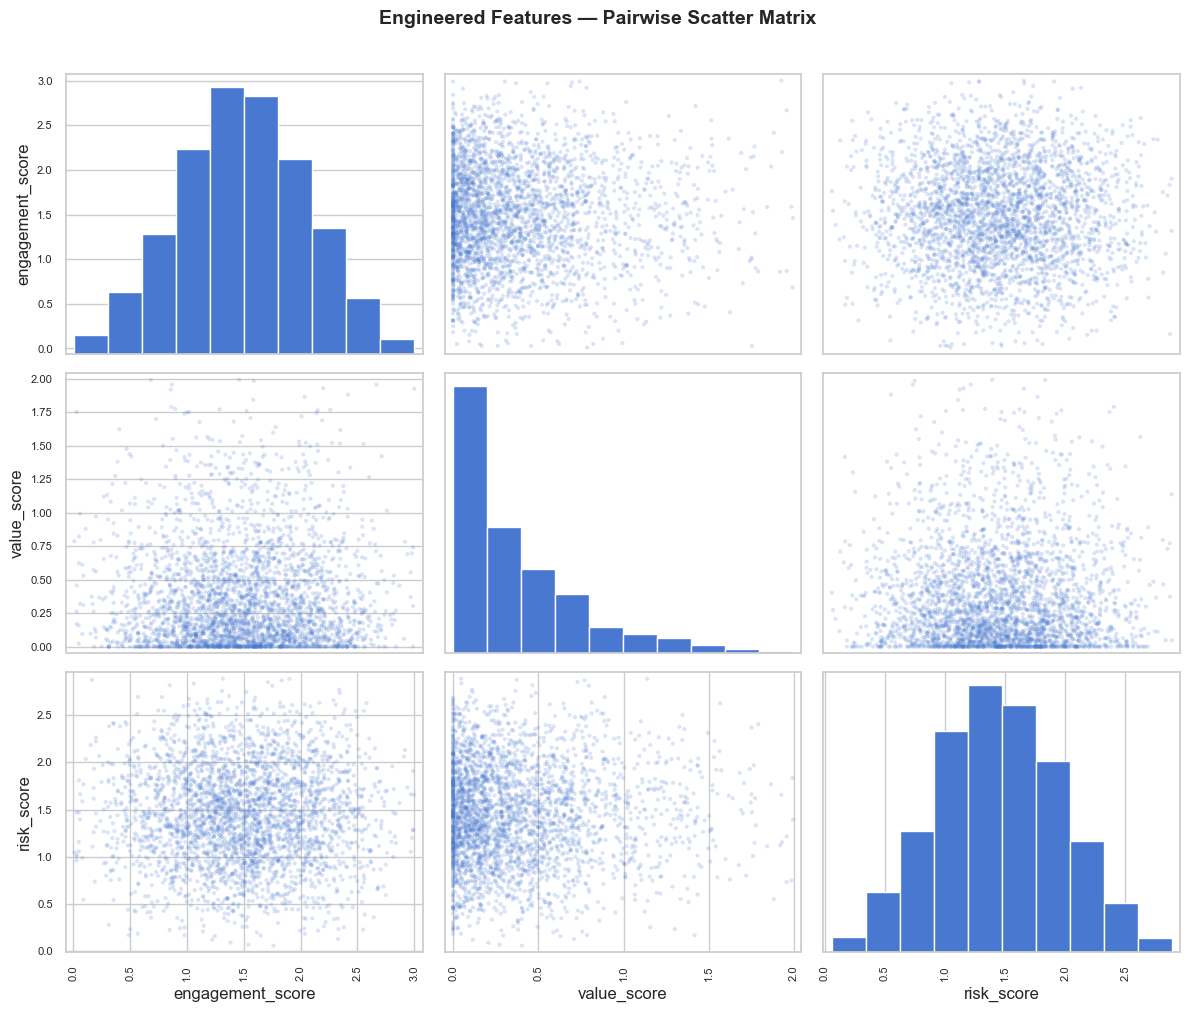

In [18]:
# ── Scatter matrix for the three engineered features ─────────────────────────
sample_plot = df[['engagement_score', 'value_score', 'risk_score']].sample(3000, random_state=42)

fig = plt.figure(figsize=(12, 10))
pd.plotting.scatter_matrix(sample_plot, alpha=0.2, figsize=(12, 10),
                            diagonal='hist', color=COLORS[0])
plt.suptitle('Engineered Features — Pairwise Scatter Matrix', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Final Feature Matrix

We now assemble three clean dataframes for downstream phases:

| File | Purpose | Scaling |
|---|---|---|
| `df_processed_raw.csv` | Reference / ML trees | Raw values + OHE + engineered features |
| `df_processed_std.csv` | Logistic Regression, Ridge, PCA | StandardScaler |
| `df_processed_mm.csv` | KMeans Clustering | MinMaxScaler |

In [19]:
# Drop the temporary age_group column from EDA if it ended up in df
if 'age_group' in df.columns:
    df = df.drop(columns=['age_group'])
    print('Dropped age_group (EDA artifact)')

# Also update std and mm dataframes with the new engineered features
for feat in ['engagement_score', 'value_score', 'risk_score']:
    df_std[feat] = df[feat]
    df_mm[feat] = df[feat]

# Optionally scale the new engineered features too
new_feats = ['engagement_score', 'value_score', 'risk_score']

df_std[new_feats] = StandardScaler().fit_transform(df[new_feats])
df_mm[new_feats]  = MinMaxScaler().fit_transform(df[new_feats])

print(f'df (raw + encoded + engineered) shape : {df.shape}')
print(f'df_std (StandardScaled) shape          : {df_std.shape}')
print(f'df_mm  (MinMaxScaled)   shape          : {df_mm.shape}')

df (raw + encoded + engineered) shape : (1000000, 851)
df_std (StandardScaled) shape          : (1000000, 851)
df_mm  (MinMaxScaled)   shape          : (1000000, 851)


In [20]:
# Final column overview
print('=== FINAL FEATURE SUMMARY ===')
final_numeric = df.select_dtypes(include=np.number).columns.tolist()
print(f'Total features (numeric) : {len(final_numeric)}')
print(f'Original numeric features: {len(scale_cols)}')
print(f'OHE features             : {len(ohe_dummy_cols)}')
print(f'Binary flags             : {len(binary_flag_cols)}')
print(f'Engineered features      : 3 (engagement_score, value_score, risk_score)')
print(f'\nMissing values in processed df: {df.isnull().sum().sum()}')

=== FINAL FEATURE SUMMARY ===
Total features (numeric) : 851
Original numeric features: 40
OHE features             : 802
Binary flags             : 5
Engineered features      : 3 (engagement_score, value_score, risk_score)

Missing values in processed df: 0


In [21]:
# Summary statistics for engineered features vs key raw features
summary_cols = ['monthly_spend', 'return_rate', 'purchase_conversion_rate',
                'engagement_score', 'value_score', 'risk_score']
summary_cols = [c for c in summary_cols if c in df.columns]

print('=== SUMMARY STATISTICS — KEY FEATURES ===')
display(df[summary_cols].describe().T.round(3)
        .style.background_gradient(cmap='Blues', subset=['mean', 'std']))

=== SUMMARY STATISTICS — KEY FEATURES ===


,count,mean,std,min,25%,50%,75%,max
monthly_spend,1000000.000000,2498.776000,1444.209000,0.000000,1249.000000,2498.000000,3750.000000,5000.000000
return_rate,1000000.000000,50.005000,29.160000,0.000000,25.000000,50.000000,75.000000,100.000000
purchase_conversion_rate,1000000.000000,50.001000,29.163000,0.000000,25.000000,50.000000,75.000000,100.000000
engagement_score,1000000.000000,1.499000,0.555000,0.000000,1.107000,1.500000,1.891000,3.000000
value_score,1000000.000000,0.375000,0.389000,0.000000,0.080000,0.251000,0.551000,2.000000
risk_score,1000000.000000,1.447000,0.515000,0.000000,1.083000,1.447000,1.810000,3.000000


## 6. Save Preprocessed Data

In [22]:
# ── Save all three versions ───────────────────────────────────────────────────
OUTPUT_RAW = 'df_processed_raw.csv'
OUTPUT_STD = 'df_processed_std.csv'
OUTPUT_MM  = 'df_processed_mm.csv'

df.to_csv(OUTPUT_RAW, index=False)
df_std.to_csv(OUTPUT_STD, index=False)
df_mm.to_csv(OUTPUT_MM, index=False)

print('✅ Preprocessed datasets saved:')
print(f'  📄 {OUTPUT_RAW}  → Raw values + encoding + features   ({df.shape})')
print(f'  📄 {OUTPUT_STD}  → StandardScaled version             ({df_std.shape})')
print(f'  📄 {OUTPUT_MM}   → MinMaxScaled version               ({df_mm.shape})')

✅ Preprocessed datasets saved:
  📄 df_processed_raw.csv  → Raw values + encoding + features   ((1000000, 851))
  📄 df_processed_std.csv  → StandardScaled version             ((1000000, 851))
  📄 df_processed_mm.csv   → MinMaxScaled version               ((1000000, 851))


In [23]:
print('=' * 65)
print('         🔧 PREPROCESSING SUMMARY')
print('=' * 65)

print('\n🔤 ENCODING')
print(f'  • Yes/No string columns encoded  : {len(yes_no_cols)}')
print(f'  • Gender label-encoded           : {"gender" in df_raw.columns}')
print(f'  • One-hot encoded columns        : {ohe_cols}')
print(f'  • OHE dummy columns created      : {len(ohe_dummy_cols)}')

print('\n📏 SCALING')
print(f'  • Columns scaled                 : {len(scale_cols)}')
print(f'  • StandardScaler → df_std        : for LR, Ridge, PCA')
print(f'  • MinMaxScaler   → df_mm         : for KMeans clustering')

print('\n⚙️  FEATURE ENGINEERING')
print(f'  • engagement_score  = norm(ad_clicks) + norm(notification_response) + norm(app_usage)')
print(f'    Mean: {df["engagement_score"].mean():.3f} | Std: {df["engagement_score"].std():.3f}')
print(f'  • value_score       = norm(spend) × loyalty_boost × norm(1+referrals)')
print(f'    Mean: {df["value_score"].mean():.4f} | Std: {df["value_score"].std():.4f}')
print(f'  • risk_score        = norm(return_rate) + norm(cart_abandonment) + norm(checkout_aband.)')
print(f'    Mean: {df["risk_score"].mean():.3f} | Std: {df["risk_score"].std():.3f}')

print('\n📦 OUTPUT FILES')
print(f'  • df_processed_raw.csv  — {df.shape}')
print(f'  • df_processed_std.csv  — {df_std.shape}')
print(f'  • df_processed_mm.csv   — {df_mm.shape}')

print('\n' + '=' * 65)
print('✅ Preprocessing Complete — Proceed to Phase 3: Segmentation')
print('=' * 65)

         🔧 PREPROCESSING SUMMARY

🔤 ENCODING
  • Yes/No string columns encoded  : 0
  • Gender label-encoded           : True
  • One-hot encoded columns        : ['country', 'urban_rural', 'employment_status', 'education_level', 'relationship_status', 'occupation', 'ethnicity', 'language_preference', 'device_type', 'preferred_payment_method', 'product_category_preference', 'shopping_time_of_day', 'budgeting_style', 'last_purchase_date']
  • OHE dummy columns created      : 802

📏 SCALING
  • Columns scaled                 : 40
  • StandardScaler → df_std        : for LR, Ridge, PCA
  • MinMaxScaler   → df_mm         : for KMeans clustering

⚙️  FEATURE ENGINEERING
  • engagement_score  = norm(ad_clicks) + norm(notification_response) + norm(app_usage)
    Mean: 1.499 | Std: 0.555
  • value_score       = norm(spend) × loyalty_boost × norm(1+referrals)
    Mean: 0.3751 | Std: 0.3886
  • risk_score        = norm(return_rate) + norm(cart_abandonment) + norm(checkout_aband.)
    Mean: 1.447

---
## ✅ Next Steps

| Phase | Notebook | Input | Description |
|-------|----------|-------|-------------|
| Phase 3 | `03_Segmentation.ipynb` | `df_processed_mm.csv` | KMeans clustering, PCA, buyer personas |
| Phase 4 | `04_ML_Models.ipynb` | `df_processed_raw.csv` / `df_processed_std.csv` | Prediction models + SHAP explainability |